# Ames Housing — Exploratory Data Analysis

Part 2 of the Ames Housing project. Continues from [`01_cleaning.ipynb`](./01_cleaning.ipynb),
which investigates and resolves all missing values in the raw dataset, producing `train_cleaned.csv`.

This notebook picks up from that cleaned checkpoint and covers univariate, bivariate, and
multivariate analysis — with a focus on testing assumptions rather than accepting surface-level
patterns, applying the same rigor built during an earlier Titanic EDA project from the outset
this time, rather than discovering it partway through.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train_cleaned.csv")  
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Setup

Recalculating column type groupings fresh from the cleaned data, since some dtypes changed
during cleaning (e.g. `MSSubClass` converted from numeric to string) and shouldn't be assumed
identical to the groupings used in the cleaning notebook.

In [2]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
object_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()

len(numeric_cols), len(object_cols)

(37, 43)

## SalePrice — Univariate Analysis

Starting with the target variable, since everything else in this analysis will eventually be
compared against it. Before looking at the data, my prediction was that `SalePrice` would be
right-skewed, similar to `Fare` in the Titanic dataset — most real-world price data clusters
around a typical value with a thinning tail of expensive outliers.

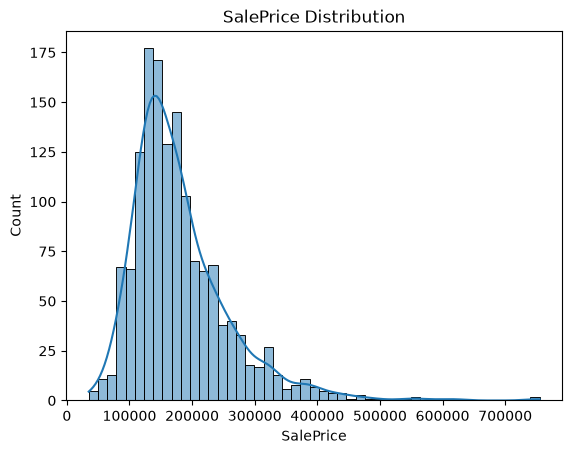

In [3]:
sns.histplot(data=df, x="SalePrice", kde=True)
plt.title("SalePrice Distribution")
plt.show()

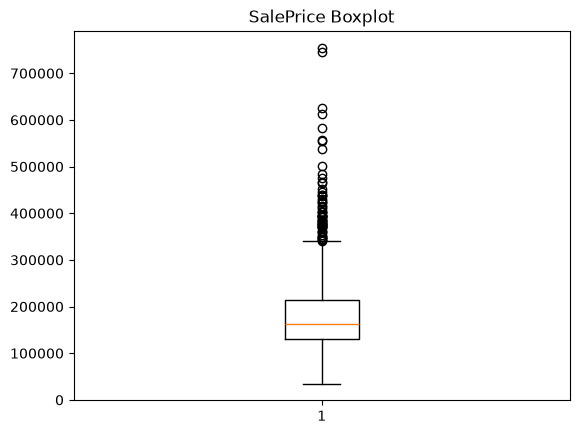

In [4]:
plt.boxplot(df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

In [5]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

**Finding:** confirmed — `SalePrice` is right-skewed, with a skew coefficient of **1.3**, well past
the threshold for strong skew. The histogram shows a sharp peak at lower-to-mid price ranges with a
long tail stretching toward expensive homes, and the boxplot shows a compressed box with several
outlier dots above it.

In [6]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**Mean vs Median:** the mean (\$180,921) sits about \$18,000 above the median (\$163,000) — exactly
what you'd expect from right-skewed data, since a small number of high-value homes pull the mean
upward without moving the median nearly as much. The median is the more representative measure of
a "typical" Ames home; the mean is inflated by outliers.

## Identifying Outliers — IQR Method

Rather than relying on an arbitrary percentile cutoff, using the IQR (Interquartile Range) rule —
the same method boxplots use internally to determine which points are drawn as outlier dots.

In [7]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < lower_bound) | (df["SalePrice"] > upper_bound)]

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")

print(f"Total SalePrice Outliers: {len(outliers)}")

outliers[["SalePrice", "PoolQC", "OverallQual", "BedroomAbvGr"]]

Lower bound: 3937.5, Upper bound: 340037.5
Number of outliers: 61
Total SalePrice Outliers: 61


,SalePrice,PoolQC,OverallQual,BedroomAbvGr
11,345000,NaN,9,4
53,385000,NaN,9,0
58,438780,NaN,10,3
112,383970,NaN,7,4
151,372402,NaN,8,2
...,...,...,...,...
1268,381000,NaN,8,4
1353,410000,NaN,8,4
1373,466500,NaN,10,2
1388,377500,NaN,9,3


**Finding:** 61 houses qualify as outliers by the IQR rule, and **all of them are upper (high-price)
outliers** — there are no lower-end outliers. This makes sense given the calculated lower bound
(~\$3,937) is far below any realistic house price (actual minimum: \$34,900), so no house could ever
fall below it. This confirms `SalePrice`'s skew is entirely driven from the high end — a "some houses
are unusually expensive" story, not a "some houses are unusually cheap" one.

Next: examining what these 61 outlier houses have in common, without yet investigating *why* — that
belongs to bivariate/multivariate analysis.

In [8]:
df_check = pd.read_csv("../data/train_cleaned.csv")
df_check.isnull().sum().sum()

np.int64(7475)

In [9]:
df.isnull().sum().sum()

np.int64(7475)